# Small Dataset Comparison: Logistic Regression vs MLP

This notebook implements the small tabular dataset comparison from the project README.

Goal:
- Use the same split and preprocessing for both models.
- Compare a classical ML baseline (Logistic Regression) against a DL baseline (MLP).
- Report fair metrics, plots, and saved artifacts.

In [2]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
DATA_CANDIDATES = [
    PROJECT_ROOT / "dataset" / "datasetSmall" / "cancer.csv",
    PROJECT_ROOT / "Data Set small" / "cancer.csv",
    PROJECT_ROOT / "Data set small" / "cancer.csv",
    PROJECT_ROOT / "datasetSmall" / "cancer.csv",
]


def resolve_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find cancer.csv. Checked: " + ", ".join(str(p) for p in candidates)
    )


DATA_PATH = resolve_existing_path(DATA_CANDIDATES)
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "small_dataset"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

for folder in [ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR, METRICS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Using dataset: {DATA_PATH}")
print(f"Artifacts folder: {ARTIFACTS_DIR}")

Project root: /teamspace/studios/this_studio
Using dataset: /teamspace/studios/this_studio/dataset/datasetSmall/cancer.csv
Artifacts folder: /teamspace/studios/this_studio/artifacts/small_dataset


## 1) Create Notebook File and Configure Environment

Core libraries, fixed random seed, and reproducible local file paths are set above.

## 2) Load Small Dataset CSV

Read the local CSV, inspect structure, and split candidate features/target columns.

In [3]:
df = pd.read_csv(DATA_PATH)

# Some local copies of this dataset have an extra trailing comma that creates an empty column.
empty_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
if empty_cols:
    df = df.drop(columns=empty_cols)

display(df.head())
print(f"Shape: {df.shape}")
print("\nDtypes:")
print(df.dtypes.value_counts())

TARGET_COL = "diagnosis"
ID_COL = "id"

if TARGET_COL not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COL}' not found in CSV.")

feature_cols = [c for c in df.columns if c not in [TARGET_COL, ID_COL]]
X_raw = df[feature_cols].copy()
y_raw = df[TARGET_COL].copy()

print(f"Feature count: {len(feature_cols)}")
print(f"Target column: {TARGET_COL}")

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Shape: (569, 32)

Dtypes:
float64    30
int64       1
object      1
Name: count, dtype: int64
Feature count: 30
Target column: diagnosis


## 3) Validate Schema, Labels, and Class Balance

Check for missing values, duplicates, unexpected types, and target encoding readiness.

In [4]:
missing_values = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total missing values: {missing_values}")
print(f"Duplicate rows: {duplicate_rows}")
print("\nTarget raw classes:")
print(y_raw.value_counts())

# Encode target consistently to binary numeric labels.
if y_raw.dtype == object:
    y = y_raw.map({"B": 0, "M": 1})
    if y.isna().any():
        unique_classes = sorted(y_raw.unique())
        class_to_int = {cls: idx for idx, cls in enumerate(unique_classes)}
        y = y_raw.map(class_to_int)
        print("Used fallback target mapping:", class_to_int)
    else:
        print("Used target mapping: {'B': 0, 'M': 1}")
else:
    y = y_raw.astype(int)
    print("Target already numeric.")

X = X_raw.apply(pd.to_numeric, errors="raise")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print("Class balance (ratio):")
print(y.value_counts(normalize=True).sort_index())

Total missing values: 0
Duplicate rows: 0

Target raw classes:
diagnosis
B    357
M    212
Name: count, dtype: int64
Used target mapping: {'B': 0, 'M': 1}

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Class balance (ratio):
diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64


## 4) Build Stratified Train/Validation/Test Split (70/15/15)

Create one fixed split with stratification and reuse it across all models.

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

val_ratio_within_train_val = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_ratio_within_train_val,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

print("Split sizes:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print("\nClass balance by split:")
for split_name, y_split in {
    "train": y_train,
    "val": y_val,
    "test": y_test,
}.items():
    print(f"{split_name}:\n{y_split.value_counts(normalize=True).sort_index()}\n")

Split sizes:
Train: 397 samples
Validation: 86 samples
Test: 86 samples

Class balance by split:
train:
diagnosis
0    0.627204
1    0.372796
Name: proportion, dtype: float64

val:
diagnosis
0    0.627907
1    0.372093
Name: proportion, dtype: float64

test:
diagnosis
0    0.627907
1    0.372093
Name: proportion, dtype: float64



## 5) Fit Shared Preprocessing on Training Data Only

Fit one StandardScaler on train features only, then transform train/validation/test consistently.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled feature arrays ready:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaled feature arrays ready:
X_train_scaled: (397, 30)
X_val_scaled:   (86, 30)
X_test_scaled:  (86, 30)


## 6) Train Logistic Regression Baseline (ML)

Train a logistic model on the shared preprocessed train data and keep outputs for interpretation and comparison.

In [7]:
def get_positive_class_scores(model, X_input):
    proba = model.predict_proba(X_input)
    if proba.ndim == 2 and proba.shape[1] > 1:
        return proba[:, 1]
    return proba.ravel()


def compute_common_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
    }


baseline_models = {}
baseline_results = []

logreg_baseline = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

start_train = time.perf_counter()
logreg_baseline.fit(X_train_scaled, y_train)
logreg_train_time = time.perf_counter() - start_train

val_pred_lr = logreg_baseline.predict(X_val_scaled)
val_score_lr = get_positive_class_scores(logreg_baseline, X_val_scaled)
val_metrics_lr = compute_common_metrics(y_val, val_pred_lr, val_score_lr)

baseline_models["logreg"] = logreg_baseline
baseline_results.append(
    {
        "model": "LogisticRegression_baseline",
        "train_time_sec": logreg_train_time,
        **{f"val_{k}": v for k, v in val_metrics_lr.items()},
    }
)

coef_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "coefficient": logreg_baseline.coef_.ravel(),
        "abs_coefficient": np.abs(logreg_baseline.coef_.ravel()),
    }
).sort_values("abs_coefficient", ascending=False)

print("Logistic Regression baseline validation metrics:")
print(pd.Series(val_metrics_lr))
print("\nTop 10 absolute coefficients:")
display(coef_df.head(10))

Logistic Regression baseline validation metrics:
accuracy           0.965116
precision_macro    0.960263
recall_macro       0.965856
f1_macro           0.962904
roc_auc            0.997685
dtype: float64

Top 10 absolute coefficients:


,feature,coefficient,abs_coefficient
10,radius_se,1.411621,1.411621
21,texture_worst,1.236282,1.236282
20,radius_worst,0.959492,0.959492
13,area_se,0.926084,0.926084
23,area_worst,0.916771,0.916771
12,perimeter_se,0.886108,0.886108
15,compactness_se,-0.837996,0.837996
22,perimeter_worst,0.836052,0.836052
7,concave points_mean,0.822472,0.822472
28,symmetry_worst,0.805147,0.805147


## 7) Train MLP Classifier Baseline (DL)

Train a feed-forward neural network on the exact same preprocessed train data and evaluate on validation split.

In [8]:
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=32,
    max_iter=400,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
)

start_train = time.perf_counter()
mlp_baseline.fit(X_train_scaled, y_train)
mlp_train_time = time.perf_counter() - start_train

val_pred_mlp = mlp_baseline.predict(X_val_scaled)
val_score_mlp = get_positive_class_scores(mlp_baseline, X_val_scaled)
val_metrics_mlp = compute_common_metrics(y_val, val_pred_mlp, val_score_mlp)

baseline_models["mlp"] = mlp_baseline
baseline_results.append(
    {
        "model": "MLP_baseline",
        "train_time_sec": mlp_train_time,
        **{f"val_{k}": v for k, v in val_metrics_mlp.items()},
    }
)

print("MLP baseline validation metrics:")
print(pd.Series(val_metrics_mlp))

MLP baseline validation metrics:
accuracy           0.965116
precision_macro    0.960263
recall_macro       0.965856
f1_macro           0.962904
roc_auc            0.995370
dtype: float64


## 8) Run Hyperparameter Search for Both Models

Use compact, fair search spaces and evaluate candidate configurations on validation data only.

In [9]:
def is_better(candidate, incumbent):
    if incumbent is None:
        return True
    if candidate["val_f1_macro"] > incumbent["val_f1_macro"]:
        return True
    if (
        candidate["val_f1_macro"] == incumbent["val_f1_macro"]
        and candidate["val_roc_auc"] > incumbent["val_roc_auc"]
    ):
        return True
    return False


def run_manual_validation_search(model_name, base_estimator, param_grid):
    records = []
    best_record = None

    for params in ParameterGrid(param_grid):
        model = clone(base_estimator)
        model.set_params(**params)

        start_train = time.perf_counter()
        model.fit(X_train_scaled, y_train)
        train_time_sec = time.perf_counter() - start_train

        val_pred = model.predict(X_val_scaled)
        val_score = get_positive_class_scores(model, X_val_scaled)
        val_metrics = compute_common_metrics(y_val, val_pred, val_score)

        record = {
            "model_family": model_name,
            "params": params,
            "train_time_sec": train_time_sec,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        records.append(record)

        if is_better(record, best_record):
            best_record = record

    return pd.DataFrame(records), best_record


logreg_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"],
    "max_iter": [2000],
}

mlp_grid = {
    "hidden_layer_sizes": [(64, 32), (128, 64), (64, 64, 32)],
    "alpha": [1e-4, 1e-3],
    "learning_rate_init": [1e-3, 5e-4],
    "max_iter": [400],
}

base_logreg = LogisticRegression(random_state=RANDOM_STATE)
base_mlp = MLPClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True,
    n_iter_no_change=20,
)

search_logreg_df, best_logreg_record = run_manual_validation_search(
    "LogisticRegression", base_logreg, logreg_grid
)
search_mlp_df, best_mlp_record = run_manual_validation_search(
    "MLPClassifier", base_mlp, mlp_grid
)

search_results = pd.concat([search_logreg_df, search_mlp_df], ignore_index=True)

display(
    search_results[
        ["model_family", "val_accuracy", "val_precision_macro", "val_recall_macro", "val_f1_macro", "val_roc_auc", "train_time_sec", "params"]
    ].sort_values(["model_family", "val_f1_macro", "val_roc_auc"], ascending=[True, False, False]).head(10)
)

print("Best validation record (LogReg):")
print(best_logreg_record)
print("\nBest validation record (MLP):")
print(best_mlp_record)

,model_family,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,train_time_sec,params
1,LogisticRegression,1.000000,1.000000,1.000000,1.000000,1.000000,0.003501,"{'C': 0.01, 'class_weight': 'balanced', 'max_i..."
2,LogisticRegression,0.988372,0.990909,0.984375,0.987476,1.000000,0.006370,"{'C': 0.1, 'class_weight': None, 'max_iter': 2..."
3,LogisticRegression,0.976744,0.975116,0.975116,0.975116,0.998843,0.005078,"{'C': 0.1, 'class_weight': 'balanced', 'max_it..."
4,LogisticRegression,0.976744,0.975116,0.975116,0.975116,0.998843,0.005649,"{'C': 1.0, 'class_weight': None, 'max_iter': 2..."
5,LogisticRegression,0.965116,0.960263,0.965856,0.962904,0.997685,0.006145,"{'C': 1.0, 'class_weight': 'balanced', 'max_it..."
6,LogisticRegression,0.953488,0.956548,0.943866,0.949560,0.994792,0.009829,"{'C': 10.0, 'class_weight': None, 'max_iter': ..."
0,LogisticRegression,0.953488,0.965517,0.937500,0.948810,1.000000,0.006794,"{'C': 0.01, 'class_weight': None, 'max_iter': ..."
7,LogisticRegression,0.941860,0.940469,0.934606,0.937382,0.994213,0.018585,"{'C': 10.0, 'class_weight': 'balanced', 'max_i..."
11,MLPClassifier,0.988372,0.990909,0.984375,0.987476,1.000000,0.128688,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ..."
17,MLPClassifier,0.988372,0.990909,0.984375,0.987476,1.000000,0.122237,"{'alpha': 0.001, 'hidden_layer_sizes': (128, 6..."


Best validation record (LogReg):
{'model_family': 'LogisticRegression', 'params': {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 2000, 'solver': 'lbfgs'}, 'train_time_sec': 0.0035005710000177714, 'val_accuracy': 1.0, 'val_precision_macro': 1.0, 'val_recall_macro': 1.0, 'val_f1_macro': 1.0, 'val_roc_auc': 1.0}

Best validation record (MLP):
{'model_family': 'MLPClassifier', 'params': {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.0005, 'max_iter': 400}, 'train_time_sec': 0.1286884159999886, 'val_accuracy': 0.9883720930232558, 'val_precision_macro': 0.990909090909091, 'val_recall_macro': 0.984375, 'val_f1_macro': 0.9874763361001893, 'val_roc_auc': 1.0}


## 9) Select Best Models Using Validation Metrics

Choose one best configuration per model family using validation macro F1 (tie-break by ROC-AUC), then retrain on training split.

In [10]:
selected_models = {}
selected_model_info = {}

selection_plan = {
    "LogisticRegression": {
        "estimator": LogisticRegression(random_state=RANDOM_STATE),
        "best_record": best_logreg_record,
    },
    "MLPClassifier": {
        "estimator": MLPClassifier(
            random_state=RANDOM_STATE,
            early_stopping=True,
            n_iter_no_change=20,
        ),
        "best_record": best_mlp_record,
    },
}

for model_family, cfg in selection_plan.items():
    best_params = cfg["best_record"]["params"]
    model = clone(cfg["estimator"]).set_params(**best_params)

    start_train = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    train_time_sec = time.perf_counter() - start_train

    val_pred = model.predict(X_val_scaled)
    val_score = get_positive_class_scores(model, X_val_scaled)
    val_metrics = compute_common_metrics(y_val, val_pred, val_score)

    selected_models[model_family] = model
    selected_model_info[model_family] = {
        "best_params": best_params,
        "train_time_sec": train_time_sec,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

pd.DataFrame(selected_model_info).T

,best_params,train_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc
LogisticRegression,"{'C': 0.01, 'class_weight': 'balanced', 'max_i...",0.011809,1.0,1.0,1.0,1.0,1.0
MLPClassifier,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ...",0.322417,0.988372,0.990909,0.984375,0.987476,1.0


## 10) Evaluate on Test Set with Common Metrics

Evaluate each selected model on untouched test data using identical metric functions.

In [11]:
test_results = {}
model_predictions = {}
model_scores = {}

for model_family, model in selected_models.items():
    y_pred = model.predict(X_test_scaled)
    y_score = get_positive_class_scores(model, X_test_scaled)

    metrics = compute_common_metrics(y_test, y_pred, y_score)
    test_results[model_family] = metrics
    model_predictions[model_family] = y_pred
    model_scores[model_family] = y_score


test_results_df = pd.DataFrame(test_results).T
test_results_df

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc
LogisticRegression,0.988372,0.990909,0.984375,0.987476,1.0
MLPClassifier,0.976744,0.982143,0.968750,0.974780,1.0


## 11) Generate Confusion Matrix and ROC-AUC Plots

Plot confusion matrices and ROC curves on the same test split for direct visual comparison.

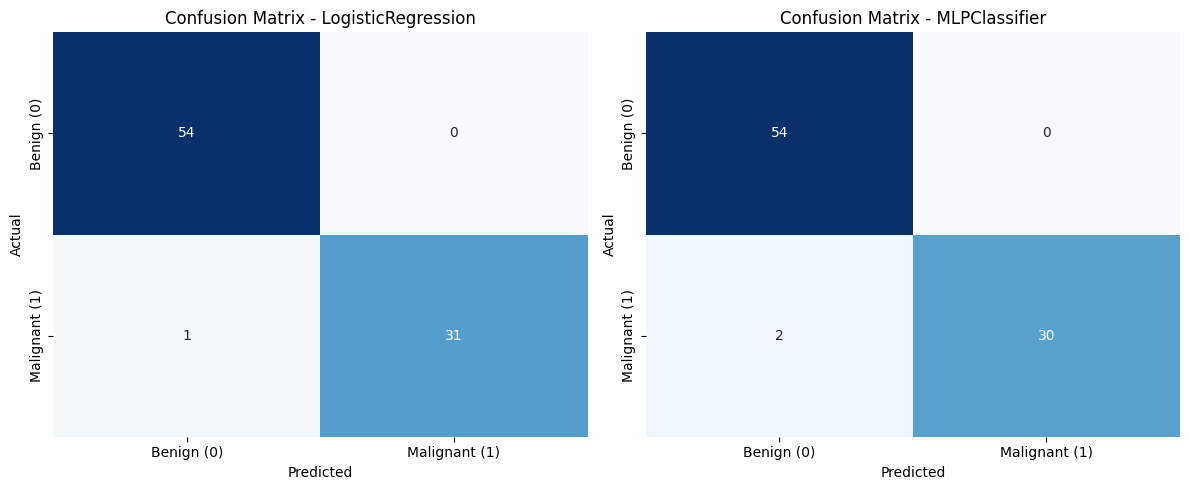

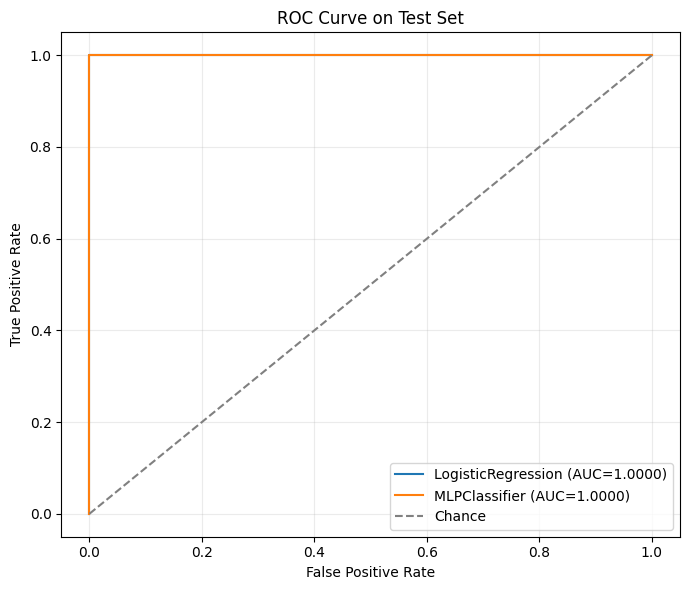

In [12]:
label_names = ["Benign (0)", "Malignant (1)"]

fig_cm, axes = plt.subplots(1, len(selected_models), figsize=(6 * len(selected_models), 5))
if len(selected_models) == 1:
    axes = [axes]

for ax, (model_family, y_pred) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {model_family}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
for model_family, y_score in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    ax_roc.plot(fpr, tpr, label=f"{model_family} (AUC={auc_value:.4f})")

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax_roc.set_title("ROC Curve on Test Set")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 12) Benchmark Training and Inference Time

Measure training and inference speed using the same methodology for both selected models.

In [13]:
timing_rows = []
n_repeats = 300

for model_family, model in selected_models.items():
    train_time_sec = selected_model_info[model_family]["train_time_sec"]

    start_infer = time.perf_counter()
    for _ in range(n_repeats):
        _ = model.predict(X_test_scaled)
    infer_total_sec = time.perf_counter() - start_infer

    infer_per_sample_ms = (infer_total_sec / (n_repeats * len(X_test_scaled))) * 1000

    timing_rows.append(
        {
            "model_family": model_family,
            "train_time_sec": train_time_sec,
            "inference_total_sec": infer_total_sec,
            "inference_per_sample_ms": infer_per_sample_ms,
        }
    )

timing_df = pd.DataFrame(timing_rows).set_index("model_family")
timing_df

,train_time_sec,inference_total_sec,inference_per_sample_ms
model_family,,,
LogisticRegression,0.011809,0.030317,0.001175
MLPClassifier,0.322417,0.113598,0.004403


## 13) Create Final Comparison Table and Save Artifacts

Build the final side-by-side table and save metrics, plots, and trained artifacts for reporting.

In [14]:
final_rows = []
for model_family in selected_models.keys():
    row = {
        "model_family": model_family,
        "val_accuracy": selected_model_info[model_family]["val_accuracy"],
        "val_precision_macro": selected_model_info[model_family]["val_precision_macro"],
        "val_recall_macro": selected_model_info[model_family]["val_recall_macro"],
        "val_f1_macro": selected_model_info[model_family]["val_f1_macro"],
        "val_roc_auc": selected_model_info[model_family]["val_roc_auc"],
        "test_accuracy": test_results[model_family]["accuracy"],
        "test_precision_macro": test_results[model_family]["precision_macro"],
        "test_recall_macro": test_results[model_family]["recall_macro"],
        "test_f1_macro": test_results[model_family]["f1_macro"],
        "test_roc_auc": test_results[model_family]["roc_auc"],
        "train_time_sec": timing_df.loc[model_family, "train_time_sec"],
        "inference_per_sample_ms": timing_df.loc[model_family, "inference_per_sample_ms"],
        "best_params": json.dumps(selected_model_info[model_family]["best_params"]),
    }
    final_rows.append(row)

final_comparison_df = pd.DataFrame(final_rows).sort_values("test_f1_macro", ascending=False)

display(final_comparison_df)

comparison_csv_path = METRICS_DIR / "final_comparison_small_dataset.csv"
comparison_json_path = METRICS_DIR / "final_comparison_small_dataset.json"
search_csv_path = METRICS_DIR / "validation_search_results_small_dataset.csv"
coefficients_csv_path = METRICS_DIR / "logreg_coefficients_small_dataset.csv"

search_results_to_save = search_results.copy()
search_results_to_save["params"] = search_results_to_save["params"].apply(json.dumps)
search_results_to_save.to_csv(search_csv_path, index=False)
final_comparison_df.to_csv(comparison_csv_path, index=False)

with open(comparison_json_path, "w", encoding="utf-8") as f:
    json.dump(final_rows, f, indent=2)

coef_df.to_csv(coefficients_csv_path, index=False)

for model_family, model in selected_models.items():
    joblib.dump(model, MODELS_DIR / f"{model_family}_best.joblib")

joblib.dump(scaler, MODELS_DIR / "standard_scaler.joblib")

with open(METRICS_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)

cm_plot_path = FIGURES_DIR / "confusion_matrices_test.png"
roc_plot_path = FIGURES_DIR / "roc_curves_test.png"
fig_cm.savefig(cm_plot_path, dpi=200, bbox_inches="tight")
fig_roc.savefig(roc_plot_path, dpi=200, bbox_inches="tight")

print("Saved artifacts:")
print(f"- {comparison_csv_path}")
print(f"- {comparison_json_path}")
print(f"- {search_csv_path}")
print(f"- {coefficients_csv_path}")
print(f"- {cm_plot_path}")
print(f"- {roc_plot_path}")
print(f"- {MODELS_DIR / 'standard_scaler.joblib'}")

,model_family,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,train_time_sec,inference_per_sample_ms,best_params
0,LogisticRegression,1.000000,1.000000,1.000000,1.000000,1.0,0.988372,0.990909,0.984375,0.987476,1.0,0.011809,0.001175,"{""C"": 0.01, ""class_weight"": ""balanced"", ""max_i..."
1,MLPClassifier,0.988372,0.990909,0.984375,0.987476,1.0,0.976744,0.982143,0.968750,0.974780,1.0,0.322417,0.004403,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [128, ..."


Saved artifacts:
- /teamspace/studios/this_studio/artifacts/small_dataset/metrics/final_comparison_small_dataset.csv
- /teamspace/studios/this_studio/artifacts/small_dataset/metrics/final_comparison_small_dataset.json
- /teamspace/studios/this_studio/artifacts/small_dataset/metrics/validation_search_results_small_dataset.csv
- /teamspace/studios/this_studio/artifacts/small_dataset/metrics/logreg_coefficients_small_dataset.csv
- /teamspace/studios/this_studio/artifacts/small_dataset/figures/confusion_matrices_test.png
- /teamspace/studios/this_studio/artifacts/small_dataset/figures/roc_curves_test.png
- /teamspace/studios/this_studio/artifacts/small_dataset/models/standard_scaler.joblib
